# SR3 · The Kalman Filter: A Hedge Ratio That Adapts

SR2 showed that the relationship between two stocks drifts over time. The Kalman filter is the standard tool for tracking a quantity that changes over time and is only seen through noisy data. Here we use it to let a pair's hedge ratio adapt day by day.

## 1. Motivation

In SR2, we fitted a hedge ratio once and froze it, and the strategy broke when the relationship changed. Re-estimating it on a rolling window helps, but forces an awkward choice. A short window reacts fast but is noisy. A long window is smooth but slow, and it treats a day from a year ago as just as informative as yesterday. Is there a principled way to update an estimate as each new day of data arrives?

## 2. Intuition

Think of a ship's navigator before GPS. Every hour they **predict** the ship's position from its last known position, speed and heading. Then they take a star sighting, which is a noisy **measurement**. The new estimate is a blend of the two. If the prediction is uncertain (rough seas) and the sighting is precise, trust the sighting more. If the sighting is fuzzy (clouds) and the prediction is solid, trust the prediction more.

The **Kalman filter** does exactly this, with the trust weights computed from the variances, every time step:

1. **Predict:** "the hedge ratio today is probably close to yesterday's", with some extra uncertainty because it may have drifted.
2. **Measure:** today's prices give a noisy reading of the relationship.
3. **Update:** move the estimate towards what today's data implies, by an amount (the **Kalman gain**) that depends on how uncertain the prediction was compared with the measurement.

As a bonus, the filter tells us how surprising today's data was. That **forecast error** turns out to be a ready-made trading signal.

## 3. The math

**State-space model.** The hidden **state** is $\theta_t = (\alpha_t, \beta_t)^\top$, the intercept and hedge ratio. We assume it follows a random walk, and that we observe it through the price relationship:
$$
\theta_t = \theta_{t-1} + w_t, \quad w_t \sim \mathcal N(0, Q) \qquad (\text{state drifts slowly})
$$
$$
y_t = H_t\,\theta_t + v_t, \quad v_t \sim \mathcal N(0, R), \quad H_t = (1,\; x_t) \qquad (\text{what we observe})
$$
Here $y_t$ and $x_t$ are the two log prices. $Q$ sets how fast the state can drift, and $R$ how noisy each observation is.

**The filter.** Let $\hat\theta_{t-1}$ be the estimate after day $t-1$ and $P_{t-1}$ its covariance (our uncertainty). Each day:

| Step | Formula | Meaning |
|---|---|---|
| Predict | $\hat\theta_{t\mid t-1} = \hat\theta_{t-1}$, $\;P_{t\mid t-1} = P_{t-1} + Q$ | best guess is yesterday's; uncertainty grows |
| Forecast error | $e_t = y_t - H_t\hat\theta_{t\mid t-1}$ | how wrong today's prediction of $y_t$ was |
| Its variance | $S_t = H_t P_{t\mid t-1} H_t^\top + R$ | how wrong we *expected* to be |
| Kalman gain | $K_t = P_{t\mid t-1}H_t^\top / S_t$ | how much to trust today's data |
| Update | $\hat\theta_t = \hat\theta_{t\mid t-1} + K_t e_t$, $\;P_t = (I - K_t H_t)P_{t\mid t-1}$ | move towards the data; uncertainty shrinks |

**Trading signal.** $e_t$ is the spread *relative to the current estimate of the relationship*, and $S_t$ is its expected variance. So
$$
z_t = \frac{e_t}{\sqrt{S_t}}
$$
is a standardised spread that adapts automatically, with no window to choose. A useful parametrisation is $Q = \tfrac{\delta}{1-\delta} I$: a small $\delta$ means a slowly drifting hedge ratio.

<details><summary><b>Where the gain comes from (click to expand)</b></summary>

With Gaussian noise, the update is Bayes' rule: the prior $\theta_t \sim \mathcal N(\hat\theta_{t\mid t-1}, P_{t\mid t-1})$ is combined with the likelihood of $y_t$. The posterior mean is linear in $e_t$, and $K_t$ is the coefficient that minimises the posterior variance. In one dimension, $K = P/(P+R)$: a weighted average that trusts whichever source has the smaller variance.
</details>

## 4. Code it

### 4.1 Setup and the filter

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
meta = pd.read_csv("../data/meta.csv")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})
logp = np.log(prices.drop(columns=["^VIX", "^IRX"]))   # log prices (the two indices are not prices)
returns = prices.pct_change()

def kalman_regression(y, x, delta=1e-4, R=1e-3):
    """Track theta_t = (alpha_t, beta_t) in y_t = alpha_t + beta_t x_t + noise."""
    n = len(y)
    theta = np.zeros(2)                   # initial guess
    P = np.eye(2)                         # large initial uncertainty
    Q = delta / (1 - delta) * np.eye(2)   # how fast the state may drift
    thetas, e, S = np.zeros((n, 2)), np.zeros(n), np.zeros(n)
    for t in range(n):
        H = np.array([1.0, x[t]])
        P = P + Q                                         # predict: uncertainty grows
        e[t] = y[t] - H @ theta                           # forecast error e_t
        S[t] = H @ P @ H + R                              # its variance S_t
        K = P @ H / S[t]                                  # Kalman gain K_t
        theta = theta + K * e[t]                          # update the state
        P = P - np.outer(K, H) @ P                        # update the uncertainty
        thetas[t] = theta
    return thetas, e, S

### 4.2 Does it track a moving target? A controlled test

Before using real data, we check the filter on simulated data where we *know* the true hedge ratio. Here it drifts slowly, then jumps halfway through.

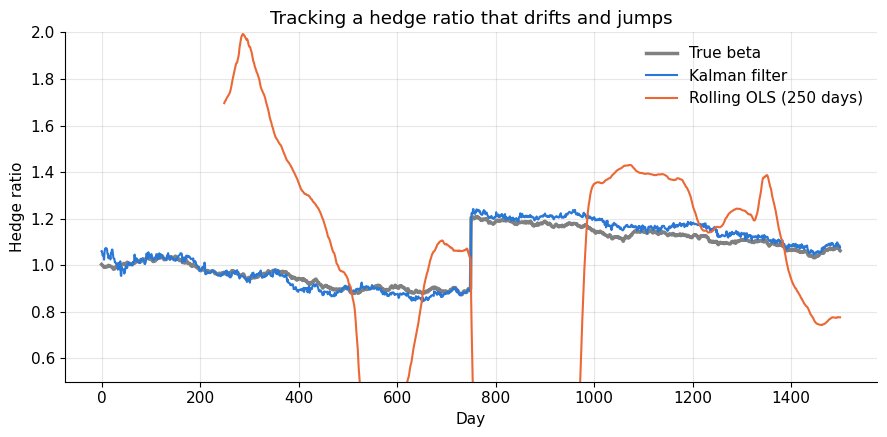

Mean absolute error: Kalman 0.025, rolling OLS 0.851


In [2]:
rng = np.random.default_rng(0)
n = 1500
x = np.cumsum(rng.normal(0, 0.02, n)) + 4              # a random-walk "log price"
true_beta = 1 + np.cumsum(rng.normal(0, 0.003, n))      # slowly drifting hedge ratio...
true_beta[n // 2:] += 0.3                               # ...with a sudden jump
y = 0.5 + true_beta * x + rng.normal(0, 0.02, n)

thetas, _, _ = kalman_regression(y, x, delta=1e-4, R=0.02**2)
sx, sy = pd.Series(x), pd.Series(y)
rolling_beta = sy.rolling(250).cov(sx) / sx.rolling(250).var()     # rolling OLS for comparison

fig, ax = plt.subplots()
ax.plot(true_beta, color="grey", label="True beta", linewidth=2.5)
ax.plot(thetas[:, 1], label="Kalman filter")
ax.plot(rolling_beta, label="Rolling OLS (250 days)")
ax.set_ylim(0.5, 2.0)
ax.set_xlabel("Day")
ax.set_ylabel("Hedge ratio")
ax.set_title("Tracking a hedge ratio that drifts and jumps")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

valid = ~np.isnan(rolling_beta.values)
print(f"Mean absolute error: Kalman {np.abs(thetas[valid, 1] - true_beta[valid]).mean():.3f}, "
      f"rolling OLS {np.abs(rolling_beta.values[valid] - true_beta[valid]).mean():.3f}")

The Kalman filter (blue) follows the true hedge ratio closely, including the jump, which it absorbs within a few days. The rolling OLS estimate (orange) is far worse. Within a one-year window, a log price moves in a fairly narrow range, so a regression on price *levels* can't reliably separate the intercept from the slope, and the estimate swings wildly. The filter avoids this. It carries forward everything it has learned, nudging the estimate a little each day, instead of re-estimating from scratch in every window.

This controlled test matters. We know the filter works when its assumptions hold, so if it later fails on real data, the cause is the data, not a bug.

### 4.3 KO/PEP: hedge ratio over time

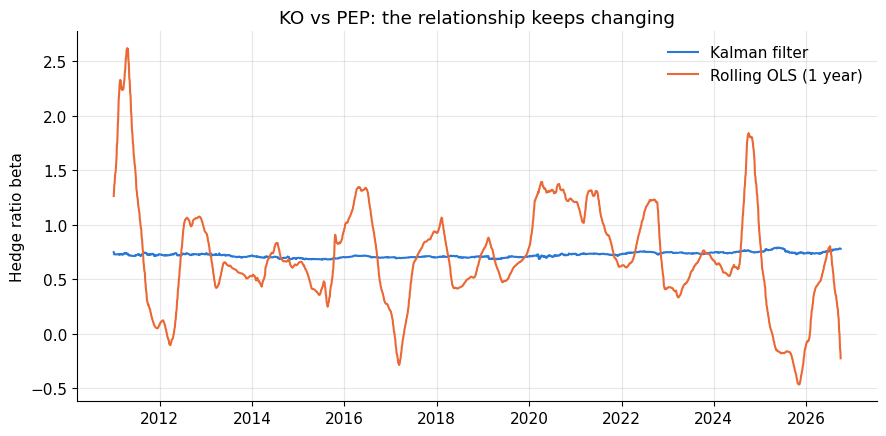

In [3]:
A, B = "KO", "PEP"
d = logp[[A, B]].dropna()
thetas, e, S = kalman_regression(d[A].values, d[B].values)
kf_beta = pd.Series(thetas[:, 1], index=d.index)
roll = d[A].rolling(252).cov(d[B]) / d[B].rolling(252).var()

fig, ax = plt.subplots()
ax.plot(kf_beta["2011":], label="Kalman filter")
ax.plot(roll["2011":], label="Rolling OLS (1 year)")
ax.set_ylabel("Hedge ratio beta")
ax.set_title(f"{A} vs {B}: the relationship keeps changing")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

On real data the two estimates look very different. The one-year rolling OLS hedge ratio swings between −0.5 and 2.6, which would make any spread built on it unstable. With the default $\delta = 10^{-4}$, the Kalman hedge ratio barely moves (about 0.7–0.8). It treats most short-term swings as noise, not as real changes. So in practice, most of what the filter adds here is not a fast-moving $\beta$, but a well-scaled, adaptive signal: the standardised forecast error $z_t = e_t/\sqrt{S_t}$.

### 4.4 Trading the Kalman spread on all 71 pairs

We now repeat the large-scale test from SR2, with the Kalman forecast error as the signal: enter when $|z_t| > 1$, exit when $z_t$ crosses 0. The parameters ($\delta = 10^{-4}$, $R = 10^{-3}$) are common textbook defaults, chosen *before* looking at results.

Portfolio of 71 Kalman pairs: Sharpe 0.23, return +0.2%/yr, volatility 1.0%
Share of pairs with positive average P&L: 62%


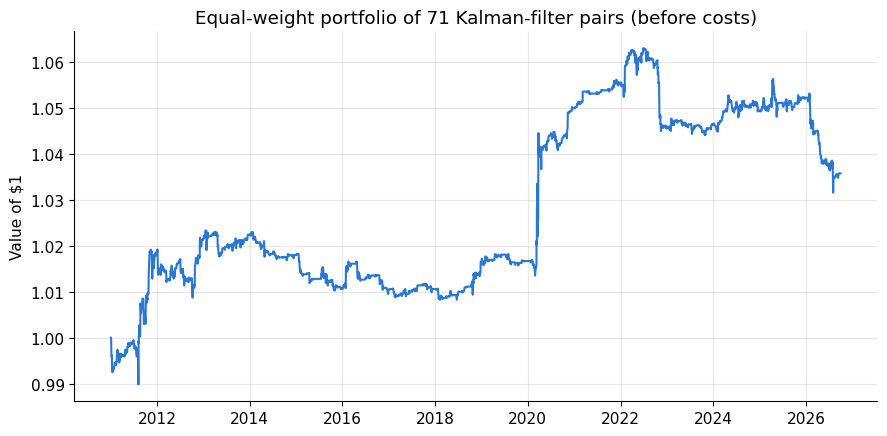

In [4]:
def positions(z, entry=1.0, exit=0.0):
    pos, out = 0, []
    for v in z:
        if pos == 0:
            pos = -1 if v > entry else (1 if v < -entry else 0)
        elif (pos == 1 and v >= -exit) or (pos == -1 and v <= exit):
            pos = 0
        out.append(pos)
    return np.array(out)

def kalman_pair_pnl(a, b, delta=1e-4, R=1e-3):
    d = logp[[a, b]].dropna()
    thetas, e, S = kalman_regression(d[a].values, d[b].values, delta, R)
    z = e / np.sqrt(S)                                                   # standardised forecast error
    pos = pd.Series(positions(z), index=d.index).shift(1)                # trade the next day
    beta = pd.Series(thetas[:, 1], index=d.index).shift(1)               # yesterday's hedge ratio
    return pos * (returns[a] - beta * returns[b]) / (1 + beta.abs())

def sharpe(r):
    return np.sqrt(252) * r.mean() / r.std()

stocks = meta[meta.asset_type == "stock"]
pairs = [(a, b) for _, g in stocks.groupby("sector") for a, b in combinations(g.ticker, 2)]
P = pd.DataFrame({f"{a}/{b}": kalman_pair_pnl(a, b) for a, b in pairs})["2011":]   # skip a warm-up year
portfolio = P.mean(axis=1)

print(f"Portfolio of {P.shape[1]} Kalman pairs: Sharpe {sharpe(portfolio):.2f}, "
      f"return {portfolio.mean() * 252:+.1%}/yr, volatility {portfolio.std() * np.sqrt(252):.1%}")
print(f"Share of pairs with positive average P&L: {(P.mean() > 0).mean():.0%}")

fig, ax = plt.subplots()
ax.plot((1 + portfolio).cumprod(), color=COLORS[0])
ax.set_ylabel("Value of $1")
ax.set_title("Equal-weight portfolio of 71 Kalman-filter pairs (before costs)")
plt.tight_layout()
plt.show()

The Kalman version does better than the rolling version in SR2. The portfolio Sharpe ratio is about 0.2 instead of −0.1, and 62% of pairs are profitable instead of 48%. But look at the scale: about 0.2% a year at 1% volatility, *before costs*. Each pair is flat most of the time and the exposure is small. Levered up to a normal risk level, this edge would be wiped out by the costs of trading 71 pairs frequently (notebook 7). It is a real but tiny statistical effect, not a strategy.

### 4.5 How much do the settings matter?

In [5]:
grid = {}
for delta in [1e-5, 1e-4, 1e-3]:
    for R in [1e-4, 1e-3]:
        pf = pd.DataFrame({f"{a}/{b}": kalman_pair_pnl(a, b, delta, R) for a, b in pairs})["2011":].mean(axis=1)
        grid[(delta, R)] = sharpe(pf)
print("Portfolio Sharpe ratio by setting:")
print(pd.Series(grid).unstack().rename_axis(index="delta", columns="R").round(2))

Portfolio Sharpe ratio by setting:
R        0.0001  0.0010
delta                  
0.00001    0.29    0.20
0.00010    0.13    0.23
0.00100   -0.27   -0.24


Five of the six settings give a Sharpe ratio between 0.1 and 0.3, so the modest result is fairly robust to $R$ and to small values of $\delta$. A large $\delta$ ($10^{-3}$) makes the hedge ratio chase every move. The spread then absorbs the very divergences we want to trade, and the result turns negative. This is the filter's version of the window-length trade-off. The difference is that it is controlled by one interpretable parameter: how fast you believe the relationship can change.

## 5. Takeaways and where it breaks

- **The Kalman filter is "predict, measure, update" with optimal weights.** It is used in navigation, robotics and economics, and here it gives a hedge ratio that adapts without choosing a window.
- **The forecast error $e_t/\sqrt{S_t}$ is a natural signal**, already standardised by the filter's own uncertainty.
- **It helped, modestly.** Across 71 pairs, the adaptive version did better than the rolling one from SR2. The edge is small, before costs, and these pairs trade often.
- **Where it breaks:** the filter assumes Gaussian noise and a random-walk state. Sudden structural breaks are tracked only gradually, and $\delta$ and $R$ must be chosen. Choosing them by looking at backtest results is overfitting (notebook 6). They can instead be estimated by maximum likelihood on a separate period.
- **Wider uses:** the same code can track a time-varying market beta (PR4), a moving average with an adaptive speed, or any regression coefficient you suspect is drifting.

**What you could build:** an adaptive-beta library for the club: a Kalman version of every rolling regression the teams use, with the forecast-error signal exposed for strategy research.